In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import scipy as sp
import pathlib
froot = pathlib.Path().cwd().parent.parent / 'Results/Figures/ISIntervals'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [162]:
def _loadISA(session,when=None):

    R = fma.regions.regions(session,phases=when,states=['sws','rem'],events='InfraSlowRhythm/infraslowaval',load_spikes=False)
    epochs = R.eventIntervals(when)
    isa = R.eventIntervals('slownr')

    _duration = lambda x: np.diff(x,axis=-1).sum()
    epochs_duration = _duration(epochs)
    isa_duration = _duration(isa)
    states = ['sws','rem','other']

    eps = 0.0001
    def windowOccupation(windows,x):
        w = fma.general.intersectIntervals((windows,x)) # intersect again with windows
        _, window_idx = fma.general.restrict(w[:,0]+eps,windows,i_ind=True)
        win_dur = np.bincount(window_idx,weights=np.diff(w).ravel(),minlength=len(windows)) # sum their duration and put it in right window
        return win_dur / (windows[0,1] - windows[0,0])

    win_lentgh = [50,5000] # (s)
    windows_i = np.linspace(0,win_lentgh[0],51)
    windows_i = np.concatenate(([windows_i[0]], np.repeat(windows_i[1:-1],2), [windows_i[-1]])).reshape((-1,2))
    windows_s = np.linspace(0,win_lentgh[1],51)
    windows_s = np.concatenate(([windows_s[0]], np.repeat(windows_s[1:-1],2), [windows_s[-1]])).reshape((-1,2))

    fraction = np.full((len(states),3),np.nan) # (state, value)
    fraction_duration = []
    fraction_interval = []
    fraction_shifted = np.full((len(states),len(windows_s)),np.nan)
    t_max = []
    for i, state in enumerate(states):
        state_intervals = R.eventIntervals(state)
        isa_state = fma.general.intersectIntervals((isa,state_intervals))

        # 1. proportions over the whole epoch
        isa_state_duration = _duration(isa_state)
        state_duration = _duration(state_intervals)
        fraction[i,0] = isa_state_duration / isa_duration # % of ISA time spent in state
        fraction[i,1] = state_duration / epochs_duration # % of recording time spent in state, reference for previous quantity
        fraction[i,2] = isa_state_duration / state_duration # % of state time spent in ISA

        # 2. proportion of ISA as a f of interval duration
        _, state_idx = fma.general.restrict(isa_state[:,0]+0.001,state_intervals,i_ind=True)
        isa_state_dur = np.bincount(state_idx,weights=np.diff(isa_state).ravel(),minlength=len(state_intervals))
        state_intervals_dur = np.diff(state_intervals).ravel()
        fraction_duration.append([state_intervals_dur, isa_state_dur/state_intervals_dur])

        # 3. proportion of ISA as a f of elapsed interval time

        fraction_interval.append([])
        for j, interval in enumerate(state_intervals):
            if _duration(interval) >= win_lentgh[0]:
                this_isa_state = isa_state[state_idx==j,:] # intersection between 'interval' and 'isa'
                # 3a. first half of the interval
                fraction_interval[-1].append([ windowOccupation(windows_i,this_isa_state-interval[0]) ])
                # 3b. second half of the interval
                fraction_interval[-1][-1].append(windowOccupation(windows_i,this_isa_state-interval[1]+win_lentgh[0]))
        fraction_interval[-1] = np.array(fraction_interval[-1]) # (interval, start/stop, window)
        if fraction_interval[-1].size == 0:
            fraction_interval[-1] = np.zeros((0,2,win_lentgh[0]))

        # 4. proportion of ISA as a f of elapsed state time
        a = fma.general.restrict(isa_state[:,0]+eps,state_intervals,shift=True) - eps
        b = fma.general.restrict(isa_state[:,1]-eps,state_intervals,shift=True) + eps
        isa_state_shifted = np.column_stack((a,b))
        fraction_shifted[i] = windowOccupation(windows_s,isa_state_shifted)
        t_max.append(state_duration)
        fraction_shifted[i,windows_s[:,1]>state_duration] = np.nan

    fraction = xr.DataArray(fraction,dims=['state','val'],coords={'state': states, 'val': ['isa','ref','reverse'], 'rat': int(R.rat)})
    state_label = np.concatenate([[states[i]]*len(fd[0]) for i, fd in enumerate(fraction_duration)])
    fraction_duration = xr.DataArray(np.concatenate(fraction_duration,axis=1),dims=['val','state'],coords={'val': ['dur','f'], 'state': state_label, 'rat': int(R.rat)})
    state_label = np.concatenate([[states[i]]*len(fd) for i, fd in enumerate(fraction_interval)])
    windows_i = windows_i.mean(axis=1)
    fraction_interval = xr.DataArray(np.concatenate(fraction_interval),dims=['state','val','win'],coords={'state': state_label, 'val': ['start','stop'], 'win': windows_i, 'rat': int(R.rat)})
    windows_s = windows_s.mean(axis=1)
    fraction_shifted = xr.DataArray(fraction_shifted,dims=['state','win'],coords={'state': states, 'win': windows_s, 'tmax': ('state', t_max), 'rat': int(R.rat)})

    return fraction, fraction_duration, fraction_interval, fraction_shifted

In [29]:
session = fma.data.readBatchFile(batch_file)[0][25]
print(session)
fraction, fraction_duration, fraction_interval, fraction_shifted = _loadISA(session,when='sleep.*#0')
states = fraction.state.values

/mnt/hubel-data-140/karadoc/Rat004_20240314/Rat004_20240314.xml


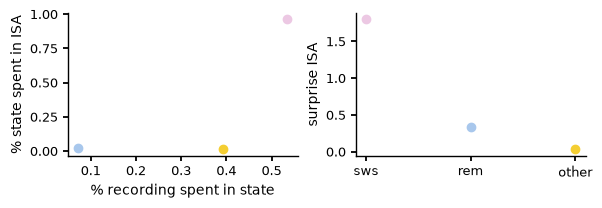

In [30]:
fig, ax = fma.plotting.makeFigure(size=(15,5),n=(1,2))
for i, state in enumerate(fraction.state.values):
    fd = fraction.sel(state=state)
    ax[0].scatter(fd.sel(val='ref'),fd.sel(val='isa'),color=isru.paperColors(state))
    ax[1].scatter(i,fd.sel(val='isa')/fd.sel(val='ref'),color=isru.paperColors(state))
ax[0].set(xlabel='% recording spent in state',ylabel='% state spent in ISA')
ax[1].set(ylabel='surprise ISA')
ax[1].set_xticks(range(len(fraction.state)),fraction.state.values);

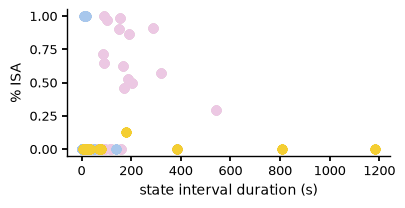

In [31]:
fig, ax = fma.plotting.makeFigure(size=(10,5))
for state in fraction_duration.state.values:
    fd = fraction_duration.sel(state=state)
    ax[0].scatter(fd[0],fd[1],color=isru.paperColors(state))
ax[0].set(xlabel='state interval duration (s)',ylabel='% ISA');

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/stats/_resampling.py:156: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/_lib/_util.py:307: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


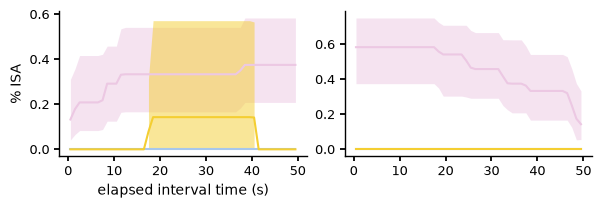

In [32]:
fig, ax = fma.plotting.makeFigure(size=(15,5),n=(1,2))
for state in states:
    fd = fraction_interval.sel(state=state)
    fma.plotting.semPlot(fd.win,fd.sel(val='start'),color=isru.paperColors(state),ax=ax[0])
    fma.plotting.semPlot(fd.win,fd.sel(val='stop'),color=isru.paperColors(state),ax=ax[1])
ax[0].set(xlabel='elapsed interval time (s)',ylabel='% ISA');

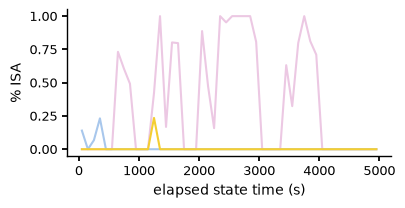

In [33]:
fig, ax = fma.plotting.makeFigure(size=(10,5))
for state in fraction_shifted.state.values:
    fd = fraction_shifted.sel(state=state)
    ax[0].plot(fd.win,fd,color=isru.paperColors(state))
ax[0].set(xlabel='elapsed state time (s)',ylabel='% ISA');

run batch

In [163]:
fraction, fraction_duration, fraction_interval, fraction_shifted = fma.data.runBatch(batch_file,_loadISA,kwargs={'when': 'sleep.*#0'},parallel=True)


Starting Batch, 2026-07-16 17:15:16.104991 



/tmp/ipykernel_247780/3812326988.py:37: RuntimeWarning: invalid value encountered in scalar divide
  fraction[i,0] = isa_state_duration / isa_duration # % of ISA time spent in state
/tmp/ipykernel_247780/3812326988.py:37: RuntimeWarning: invalid value encountered in scalar divide
  fraction[i,0] = isa_state_duration / isa_duration # % of ISA time spent in state
/tmp/ipykernel_247780/3812326988.py:37: RuntimeWarning: invalid value encountered in scalar divide
  fraction[i,0] = isa_state_duration / isa_duration # % of ISA time spent in state
/tmp/ipykernel_247780/3812326988.py:37: RuntimeWarning: invalid value encountered in scalar divide
  fraction[i,0] = isa_state_duration / isa_duration # % of ISA time spent in state
/tmp/ipykernel_247780/3812326988.py:37: RuntimeWarning: invalid value encountered in scalar divide
  fraction[i,0] = isa_state_duration / isa_duration # % of ISA time spent in state
/tmp/ipykernel_247780/3812326988.py:37: RuntimeWarning: invalid value encountered in scala

Error in session /mnt/hubel-data-131/perceval/Rat003_20231218/Rat003_20231218.xml (4)
all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 8 and the array at index 1 has size 7
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.xml (41)
/mnt/hubel-data-129/blinky/Rat002_20230822/Rat002_20230822.sws not found.
Trac

In [164]:
fraction_cat = xr.concat([d for d in fraction if d is not None],dim='rat',coords='different',join='outer')
f_interval_cat = xr.concat([d.groupby('state').mean(dim='state',skipna=True) for d in fraction_interval if d is not None],dim='rat',coords='different',join='outer')
f_shifted_cat = xr.concat([d for d in fraction_shifted if d is not None],dim='rat',coords='different',join='outer')
states = fraction_cat.state.values

/tmp/ipykernel_247780/3714695182.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  fraction_cat = xr.concat([d for d in fraction if d is not None],dim='rat',coords='different',join='outer')
/tmp/ipykernel_247780/3714695182.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  f_interval_cat = xr.concat([d.groupby('state').mean(dim='state',skipna=True) for d in fraction_interval if d is not None],dim='rat',coords='different',join='outer')
/tmp/ipykernel_247780/3714695182.p

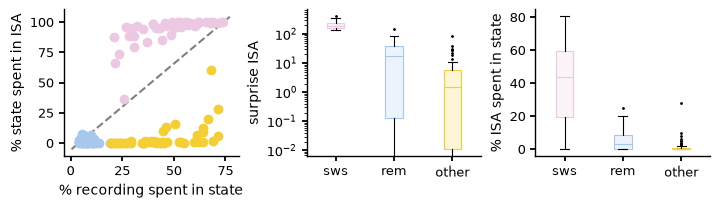

In [165]:
states = fraction_cat.state.values
fig, ax = fma.plotting.makeFigure(size=(18,5),n=(1,3))

for i, state in enumerate(states):
    fd = fraction_cat.sel(state=state)
    ax[0].scatter(fd.sel(val='ref')*100,fd.sel(val='isa')*100,color=isru.paperColors(state))
ax[0].set(xlabel='% recording spent in state',ylabel='% state spent in ISA')
ax[0].plot(ax[0].get_xlim(),ax[0].get_ylim(),color='gray',ls='--',label='1:1',zorder=-1)

fma.plotting.boxPlot(100*(fraction_cat.sel(val='isa') / fraction_cat.sel(val='ref')).T,color=isru.paperColors(states),label=states,ax=ax[1])
ax[1].set(yscale='log',ylabel='surprise ISA')

fma.plotting.boxPlot(100*fraction_cat.sel(val='reverse').T,color=isru.paperColors(states),label=states,ax=ax[2])
ax[2].set(ylabel='% ISA spent in state');

In [166]:
f_duration_cat = {}
rat = []
t_max = [600,60,700]
for i, state in enumerate(states):
    f_duration_cat[state] = []
    bins = np.linspace(0,t_max[i],20)
    for i, fd in enumerate(fraction_duration):
        if fd is not None:
            mean_f, _, _ = sp.stats.binned_statistic(fd.sel(state=state,val='dur'), fd.sel(state=state,val='f'), statistic='mean', bins=bins)
            f_duration_cat[state].append(mean_f)
            if state == states[0]:
                rat.append(fd.rat)
    f_duration_cat[state] = xr.DataArray(f_duration_cat[state],dims=['rat','dur'],coords={'rat': rat, 'dur': (bins[:-1] + bins[1:]) / 2})

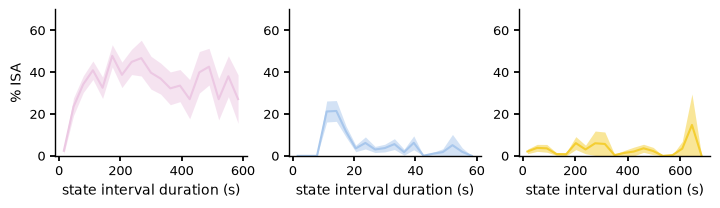

In [167]:
fig, ax = fma.plotting.makeFigure(size=(18,5),n=(1,3))
for i, state in enumerate(f_duration_cat):
    fd = f_duration_cat[state]
    fma.plotting.semPlot(fd.dur,fd*100,color=isru.paperColors(state),ci='nansem',ax=ax[i])
    ax[i].set(xlabel='state interval duration (s)',ylim=[0,70])
ax[0].set(xlabel='state interval duration (s)',ylabel='% ISA');

/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/stats/_resampling.py:156: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)
/home/pietro/uvEnvs/fmat_edit_12/lib/python3.12/site-packages/scipy/_lib/_util.py:307: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


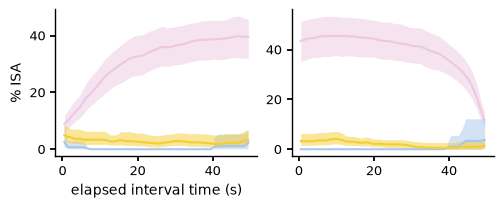

In [168]:
fig, ax = fma.plotting.makeFigure(size=(12.5,5),n=(1,2))
for state in states:
    fd = f_interval_cat.sel(state=state)
    fma.plotting.semPlot(fd.win,fd.sel(val='start')*100,color=isru.paperColors(state),ax=ax[0])
    fma.plotting.semPlot(fd.win,fd.sel(val='stop')*100,color=isru.paperColors(state),ax=ax[1])
ax[0].set(xlabel='elapsed interval time (s)',ylabel='% ISA');

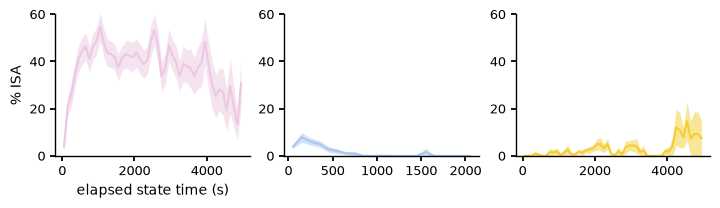

In [173]:
fig, ax = fma.plotting.makeFigure(size=(18,5),n=(1,3))
for i, state in enumerate(f_shifted_cat.state.values):
    fd = f_shifted_cat.sel(state=state)
    fma.plotting.semPlot(fd.win,fd*100,color=isru.paperColors(state),ax=ax[i],ci='nansem')
    ax[i].set(ylim=[0,60])
ax[0].set(xlabel='elapsed state time (s)',ylabel='% ISA');